In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from random import random
from hmmlearn import hmm

# Simulasi Monte Carlo

,count,mean,std,min,10%,40%,50%,70%,90%,max
0,1000.0,4.088142e+07,2.362224e+07,4220274.0,16115308.0,30001021.4,35154235.5,48112391.1,74024574.7,162940400.0


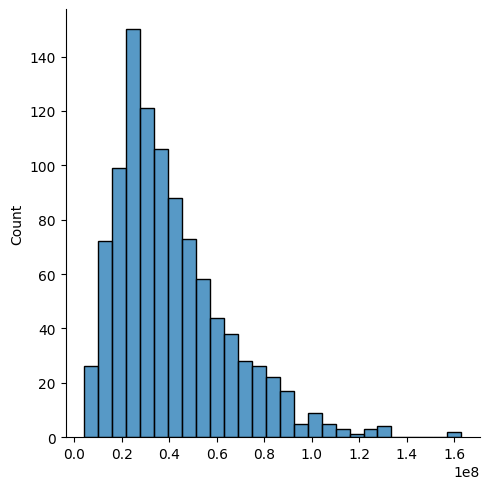

In [42]:
luas = np.random.triangular(1000000, 2000000, 4000000, 1000).round()

ketebalan = np.random.triangular(10, 20, 40, 1000).round()
sw = np.random.triangular(0.1, 0.2, 0.3, 1000).round(2)
phi = np.random.triangular(0.1, 0.3, 0.5, 1000).round(1)
ngr = np.random.triangular(0.2, 0.4, 0.9, 1000).round(1)
bo = np.random.uniform(1, 1, 1000).round()
def ooip(luas, ketebalan, sw, phi, ngr, bo, metric=True):
    so = 1 - sw
    ooip = 7758 * (luas * 0.000247105) * (ketebalan * 3.28084) * so * phi * ngr / bo
    return ooip

cadangan = ooip(luas, ketebalan, sw, phi, ngr, bo, metric = True).round()

sns.displot(cadangan)

df = pd.DataFrame(cadangan)
df.describe(percentiles=[.10, .40, .70, .90]).T

# Simulasi Markov Chain

In [ ]:
States = ["Tidur","Eskrim","Lari"]

NamaTransisi = [["TT","TE","TL"],["ET","EE","EL"],["LT","LE","LL"]]

TransisiMatriks = [[0.2,0.6,0.2],[0.1,0.6,0.3],[0.2,0.7,0.1]]

if sum(TransisiMatriks[0])+sum(TransisiMatriks[1])+sum(TransisiMatriks[2]) != 3:
    print("Entah apa yang salah. Mungkin matriks transisi?")
else: print("Semuanya akan baik-baik saja, kamu harus move on!! ;)")

def perkiraan_aktivitas(hari):
    aktivitasHariIni = "Tidur"
    print("State Awal: " + aktivitasHariIni)
    daftaraktivitas = [aktivitasHariIni]
    i = 0
    prob = 1
    while i != hari:
        if aktivitasHariIni == "Tidur":
            change = np.random.choice(NamaTransisi[0],replace=True,p=TransisiMatriks[0])
            if change == "TT":
                prob = prob * 0.2
                daftaraktivitas.append("Tidur")
                pass
            elif change == "TE":
                prob = prob * 0.6
                aktivitasHariIni = "Eskrim"
                daftaraktivitas.append("Eskrim")
            else:
                prob = prob * 0.2
                aktivitasHariIni = "Lari"
                daftaraktivitas.append("Lari")
        elif aktivitasHariIni == "Eskrim":
            change = np.random.choice(NamaTransisi[1],replace=True,p=TransisiMatriks[1])
            if change == "ET":
                prob = prob * 0.1
                daftaraktivitas.append("Tidur")
                pass
            elif change == "EE":
                prob = prob * 0.6
                aktivitasHariIni = "Eskrim"
                daftaraktivitas.append("Eskrim")
            else:
                prob = prob * 0.3
                aktivitasHariIni = "Lari"
                daftaraktivitas.append("Lari")
        elif aktivitasHariIni == "Lari":
            change = np.random.choice(NamaTransisi[2],replace=True,p=TransisiMatriks[2])
            if change == "LT":
                prob = prob * 0.2
                daftaraktivitas.append("Tidur")
                pass
            elif change == "LE":
                prob = prob * 0.7
                aktivitasHariIni = "Eskrim"
                daftaraktivitas.append("Eskrim")
            else:
                prob = prob * 0.1
                aktivitasHariIni = "Lari"
                daftaraktivitas.append("Lari")
        i += 1  
    print("Kemungkinan urutan keadaan aktivitas: " + str(daftaraktivitas))
    print("Status akhir menyatakan "+ str(hari) + " hari: " + aktivitasHariIni)
    print("Probabilitas urutan keadaan yang mungkin terjadi: " + str(prob))

perkiraan_aktivitas(2)

Semuanya akan baik-baik saja, kamu harus move on!! ;)
State Awal: Tidur
Kemungkinan urutan keadaan aktivitas: ['Tidur', 'Eskrim', 'Tidur']
Status akhir menyatakan 2 hari: Eskrim
Probabilitas urutan keadaan yang mungkin terjadi: 0.06


# Hidden Markov Chain

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'


                    Formatted Date        Summary Precip Type  \
0    2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain   
1    2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain   
2    2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain   
3    2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain   
4    2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain   
..                             ...            ...         ...   
995  2006-08-02 11:00:00.000 +0200  Mostly Cloudy        rain   
996  2006-08-02 12:00:00.000 +0200  Mostly Cloudy        rain   
997  2006-08-02 13:00:00.000 +0200  Partly Cloudy        rain   
998  2006-08-02 14:00:00.000 +0200  Partly Cloudy        rain   
999  2006-08-02 15:00:00.000 +0200  Mostly Cloudy        rain   

     Temperature (C)  Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0           9.472222                  7.388889      0.89            14.1197   
1           9.355556                  7.227778      0.86     

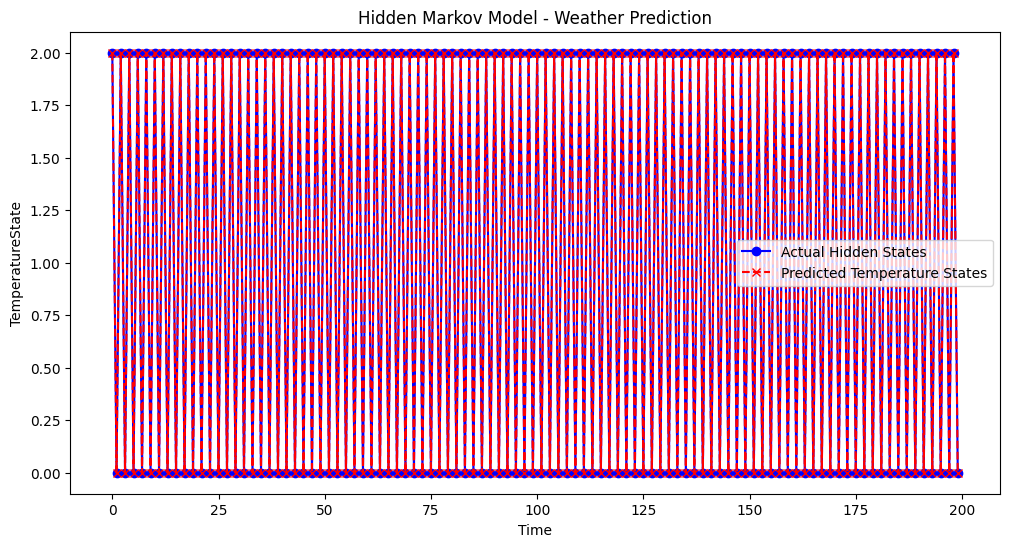

In [ ]:
data = pd.read_csv("c:/Users/Benhard Leroy/Downloads/weatherHistory.csv")
data = data.dropna()
data = data.head(1000)
print(data.head(1000))

data['Precip Type'] = data['Precip Type'].map({'rain': 1, 'snow': 2, 'NA': 0})
data['Temperature (C)'] = pd.cut(data['Temperature (C)'], bins=[-np.inf, 5, 15, np.inf], labels=[0, 1, 2]).astype(int)
temp_state_map = {0: 0, 1: 1, 2: 2} # 0 = Dingin, 1 = Sedang, 2 = Panas

model = hmm.MultinomialHMM(n_components=3, n_iter=100)
model.startprob_ = np.array([0.8, 0.4, 0.2])
model.transmat_ = np.array([[0.6, 0.3, 0.2], [0.2, 0.4, 0.1], [0.2, 0.5, 0.7]])
model.emissionprob_ = np.array([[0.8, 0.5, 0.4], [0.1, 0.3, 0.7], [0.2, 0.5, 0.5]])

observations = data[['Precip Type']].values.reshape(-1, 1)
model.fit(observations)
hidden_states = model.predict(observations)

predicted_temp_states = [temp_state_map[state] for state in hidden_states]
plt.figure(figsize=(12, 6))
plt.plot(hidden_states[:200], color='blue', marker='o', linestyle='-', label='Actual Hidden States')
plt.plot(predicted_temp_states[:200], color='red', marker='x', linestyle='--', label='Predicted Temperature States')
plt.xlabel('Time')
plt.ylabel('TemperatureState')
plt.title('Hidden Markov Model - Weather Prediction')
plt.legend()
plt.show()


## Sumber Data
#### 1. https://medium.com/@izza.aditya.12.ia/simulasi-monte-carlo-ff38dc8abeac
#### 2. https://www.datacamp.com/tutorial/markov-chains-python-tutorial?utm_cid=19589720824&utm_aid=157156376311&utm_campaign=230119_1-ps-other~dsa-tofu~all_2-b2c_3-apac_4-prc_5-na_6-na_7-le_8-pdsh-go_9-nb-e_10-na_11-na&utm_loc=9121261-&utm_mtd=-c&utm_kw=&utm_source=google&utm_medium=paid_search&utm_content=ps-other~apac-en~dsa~tofu~tutorial~python&gad_source=1&gad_campaignid=19589720824&gbraid=0AAAAADQ9WsEDMU78wALcmI7e-hfvVoQz3&gclid=CjwKCAjwyYPOBhBxEiwAgpT8PxRDH4K-WUaGhGpzg3jMJ_nPw-9TMrynZoo65gO35hW1QpYQL6mkmhoCCMMQAvD_BwE
#### 3. https://www.geeksforgeeks.org/machine-learning/hidden-markov-models-with-scikit-learn/